# 3. Bias, Variance, and the Role of Over-Parameterization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the datasets
data = np.load('hw1_p3.npy')
ground_truth = np.load('hw1_p3_gt.npy')

In [ ]:
def solve_mse(M):
    # Generate the basis functions
    mu = np.linspace(-5, 5, M+2)[1:-1]  # Means for the basis functions
    s = 2 / (M + 1)  # Scale for the basis functions

    # Function to create the design matrix
    def design_matrix(X, mu, s):
        return np.exp(-(X[:, None] - mu[None, :]) ** 2 / (2 * s ** 2))

    # Calculate weights for each dataset
    weights = []
    for i in range(data.shape[0]):
        X = data[i, :, 0]
        y = data[i, :, 1]
        Phi = design_matrix(X, mu, s)
        w = np.linalg.pinv(Phi) @ y  # Closed form solution (pseudo-inverse of Phi times y)
        weights.append(w)

    # Calculate f_hat for each dataset using the ground truth x values
    f_hats = []
    X_gt = ground_truth[0]
    for w in weights:
        Phi_gt = design_matrix(X_gt, mu, s)
        f_hat = Phi_gt @ w
        f_hats.append(f_hat)

    # Plot each f_i vs f* in a 2x5 subplot
    plt.figure(figsize=(20, 10))  # Create a large plot
    for i, f_hat in enumerate(f_hats):
        plt.subplot(2, 5, i + 1)
        plt.plot(X_gt, f_hat, label=f"f_{i}")
        plt.plot(ground_truth[0], ground_truth[1], label="f*", linestyle='--')
        plt.legend()
    plt.show()

    # Calculate the average of the regression functions
    f_bar = np.mean(f_hats, axis=0)

    # Plot f_bar against f*
    plt.figure()
    plt.plot(X_gt, f_bar, label="f_bar")
    plt.plot(ground_truth[0], ground_truth[1], label="f*", linestyle='--')
    plt.legend()
    plt.show()

    # Calculate bias and variance
    bias = np.mean((f_bar - ground_truth[1])**2)
    variance = np.mean(np.var(f_hats, axis=0))

    print("No. of basis functions:",M)
    print("Bias:", bias)
    print("Variance:", variance)

## sub-problem 1

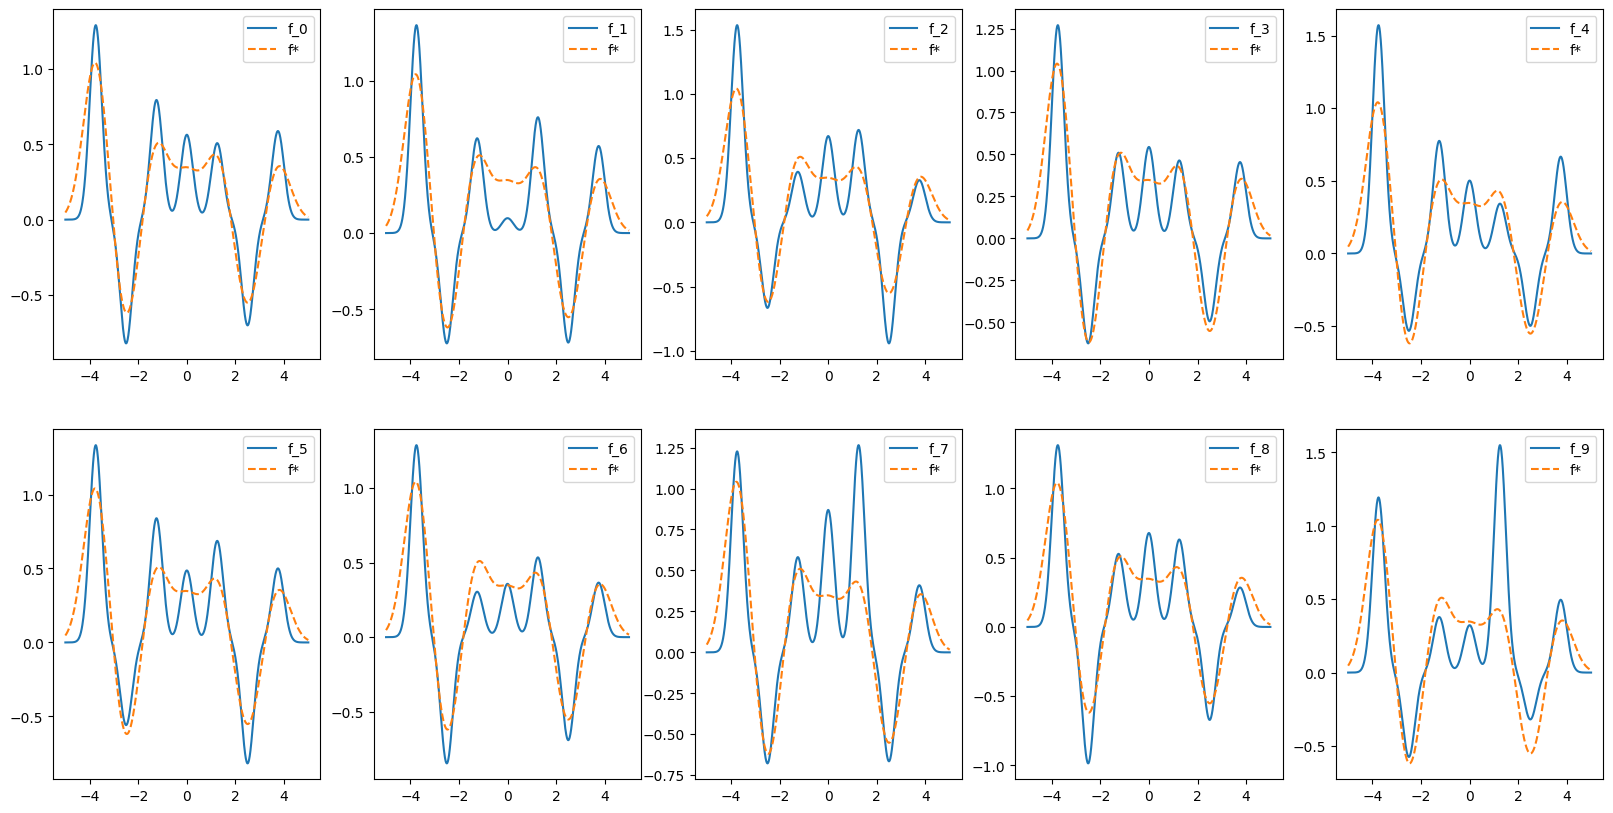

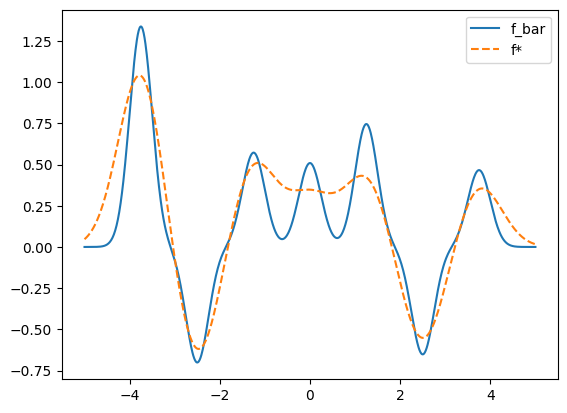

No. of basis functions: 7
Bias: 0.029364593175899095
Variance: 0.012152520458277248


In [ ]:
solve_mse(7)

## sub-problem 2

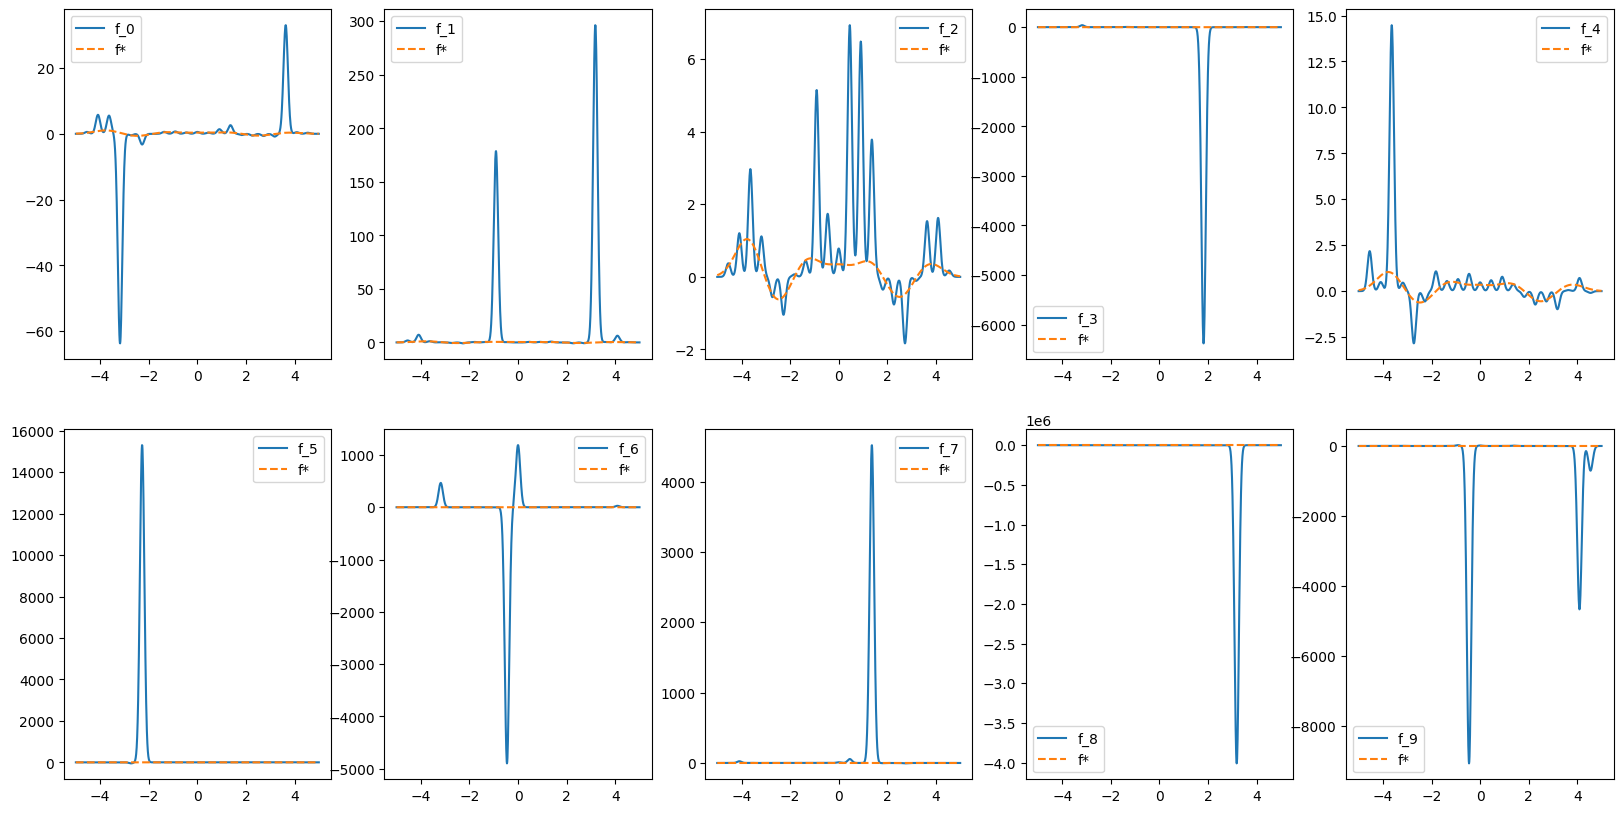

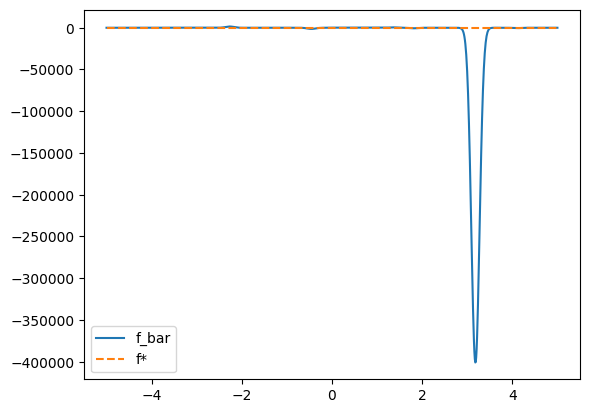

No. of basis functions: 21
Bias: 2591805408.9199266
Variance: 23329895341.28422


In [ ]:
solve_mse(21)

The comparison between the models with M = 7 and M = 21 based on the plots is as follows:

**Model with M = 7:**
- The plots show the individual $f_{i}$ functions for each set of observations. They are generally close to the ground truth $f^{*}$ without extreme fluctuations, indicating a good fit.
- There is consistency among the different $f_{i}$ functions, suggesting that the model with M = 7 has a low variance.
- The average function $\bar{f}$ closely follows the ground truth $f^{*}$, indicating that the bias is low, which suggests that the model is capturing the underlying trend well.

**Model with M = 21:**
- The individual $f_{i}$ functions exhibit significant spikes and deviations from the ground truth $f^{*}$, especially at the boundaries, reflecting a model that is likely overfitting the data.
- The inconsistency among the $f_{i}$ functions, particularly the large spikes, suggests a high variance, as the model is sensitive to the particular noise in each dataset.
- The average function $\bar{f}$ has large deviations from $f^{*}$, especially at the boundaries. However, across the domain, it appears to follow the ground truth closely, suggesting that while the bias may be low, the extreme sensitivity to noise is a problem.

**Comparison:**
- The model with M = 7 appears to be more stable and generalizable. It does not capture the noise as much as the model with M = 21, resulting in a more reliable prediction across different datasets.
- The model with M = 21, while potentially capturing the underlying trend within the data, exhibits overfitting, indicated by the large spikes in the predictions. This suggests that it has a high variance and may not generalize well to unseen data.
- In terms of bias, both models might have a low bias as they attempt to fit the ground truth, but the overfitting in the M = 21 model overshadows the benefits of a complex model.

**Conclusion:**
The model with M = 7 strikes a better balance between bias and variance, making it more suitable for generalization. The model with M = 21, despite having a possibly low bias, suffers from high variance, leading to overfitting and poor generalization. It is crucial to select a model complexity that captures the underlying data trend while avoiding the capture of noise to ensure that the model generalizes well to new, unseen data.

## sub-problem 3

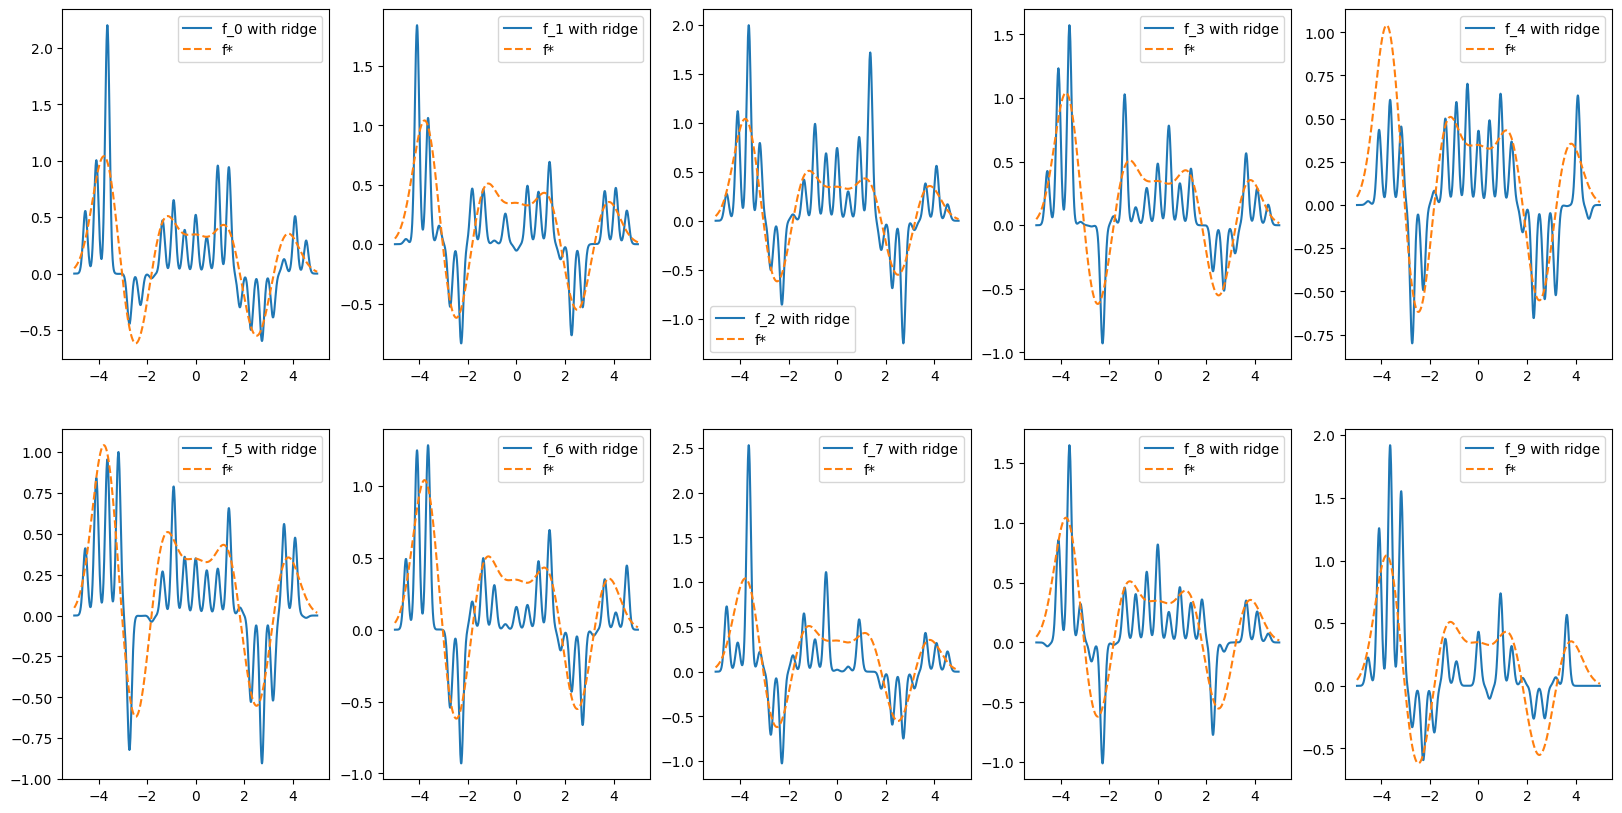

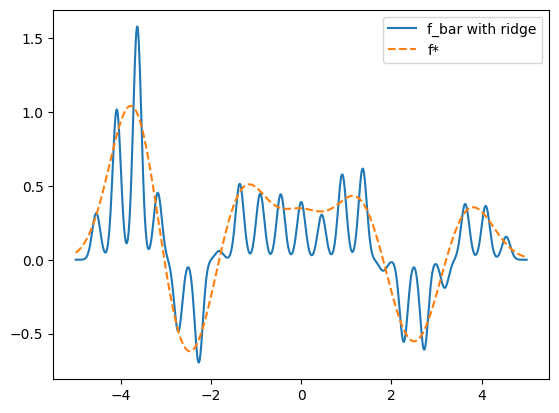

Bias with ridge regression: 0.06307252212763556
Variance with ridge regression: 0.030472654654432444


In [ ]:
# Constants for ridge regression
M = 21  # Number of basis functions
lambda_ = 0.1  # Regularization parameter

# Generate the basis functions for M = 21
mu = np.linspace(-5, 5, M+2)[1:-1]  # Means for the basis functions
s = 2 / (M + 1)  # Scale for the basis functions

# Function to create the design matrix
def design_matrix(X, mu, s):
    return np.exp(-(X[:, None] - mu[None, :]) ** 2 / (2 * s ** 2))

# Calculate ridge regression weights for each dataset
weights_ridge = []
for i in range(data.shape[0]):
    X = data[i, :, 0]
    y = data[i, :, 1]
    Phi = design_matrix(X, mu, s)
    w_ridge = np.linalg.inv(Phi.T @ Phi + lambda_ * np.eye(Phi.shape[1])) @ Phi.T @ y
    weights_ridge.append(w_ridge)

# Calculate f_hat for each dataset using the ground truth x values for ridge regression
f_hats_ridge = []
X_gt = ground_truth[0]
for w in weights_ridge:
    Phi_gt = design_matrix(X_gt, mu, s)
    f_hat = Phi_gt @ w
    f_hats_ridge.append(f_hat)

# Plot each f_i vs f* for ridge regression in a 2x5 subplot
plt.figure(figsize=(20, 10))  # Create a large plot for ridge regression
for i, f_hat in enumerate(f_hats_ridge):
    plt.subplot(2, 5, i + 1)
    plt.plot(X_gt, f_hat, label=f"f_{i} with ridge")
    plt.plot(ground_truth[0], ground_truth[1], label="f*", linestyle='--')
    plt.legend()
plt.show()

# Calculate the average of the regression functions for ridge regression
f_bar_ridge = np.mean(f_hats_ridge, axis=0)

# Plot f_bar against f* for ridge regression
plt.figure()
plt.plot(X_gt, f_bar_ridge, label="f_bar with ridge")
plt.plot(ground_truth[0], ground_truth[1], label="f*", linestyle='--')
plt.legend()
plt.show()

# Calculate bias and variance for ridge regression
bias_ridge = np.mean((f_bar_ridge - ground_truth[1])**2)
variance_ridge = np.mean(np.var(f_hats_ridge, axis=0))

print("Bias with ridge regression:", bias_ridge)
print("Variance with ridge regression:", variance_ridge)

The application of ridge regression has effectively countered the overfitting problem seen with M = 21 without regularization. The model now not only fits the training data better but is also expected to generalize much better to new data, thus showing improvements in bias and variance,demonstrating the benefits of regularization.